In [46]:
import os

print(os.environ['PYTHONHASHSEED'])

0


In [47]:
from gerrychain import Graph, Partition, MarkovChain, Election, updaters, constraints, accept
from gerrychain.proposals import recom
from gerrychain.constraints import contiguous
from gerrychain.tree import bipartition_tree
from functools import partial
from tqdm import tqdm
import random
random.seed(2024)

In [53]:
# Load the graph in from the provided json file
graph = Graph.from_json("./PA_VTDs_clean.json")

# Set up election updater
election = Election("PRES12", {"Dem" : "PRES12D", "Rep": "PRES12R"})

# Set up updaters
my_updater = {
    "population": updaters.Tally("TOT_POP", alias="population"),
    "cut_edges": updaters.cut_edges,
    "PRES12" : election
}

# Set up the initial partition object
initial_partition = Partition(
    graph,
    assignment = "2011_PLA_1",
    updaters = my_updater
)

ideal_population = sum(initial_partition["population"].values()) / len(initial_partition)
# print(f"ideal population: {ideal_population}")
print(list(initial_partition.updaters.keys()))
# create new function from the recom with our given arguments
proposal = partial(
    recom,
    pop_col="TOT_POP",
    pop_target=ideal_population,
    epsilon=0.01,
    node_repeats=2,
    method = partial(
        bipartition_tree,
        max_attempts=100,
        allow_pair_reselection=True 
    )
)

['cut_edges', 'population', 'PRES12']


In [ ]:
num_of_ensembles = 5
ensemble_list = []

outer_bar = tqdm(range(num_of_ensembles), desc="Ensembles", position=0)
for run in outer_bar:
    cur_chain = MarkovChain(
        proposal=proposal,
        constraints=[contiguous],
        accept=accept.always_accept,
        initial_state=initial_partition,
        total_steps=50
    )
    
    final_partition = None
    
    for item in cur_chain:
        final_partition = item
    
    ensemble_list.append(final_partition)

print(f"Collected {len(ensemble_list)} district plans")  


['cut_edges', 'population', 'PRES12']


Ensembles: 100%|██████████| 5/5 [00:43<00:00,  8.73s/it]

['cut_edges', 'population', 'PRES12']
Collected 5 district plans


In [57]:
for i, partition in enumerate(ensemble_list):
    pops = partition["population"].values()
    print(f"Plan {i+1}: cut_edges={len(partition['cut_edges'])} | "
          f"min_pop={min(pops):,} | max_pop={max(pops):,}")

Plan 1: cut_edges=1697 | min_pop=697,702 | max_pop=710,797
Plan 2: cut_edges=1755 | min_pop=698,983 | max_pop=711,313
Plan 3: cut_edges=1813 | min_pop=698,171 | max_pop=711,234
Plan 4: cut_edges=1603 | min_pop=698,112 | max_pop=709,904
Plan 5: cut_edges=1854 | min_pop=697,759 | max_pop=711,122


Matched: 8921 / 9255


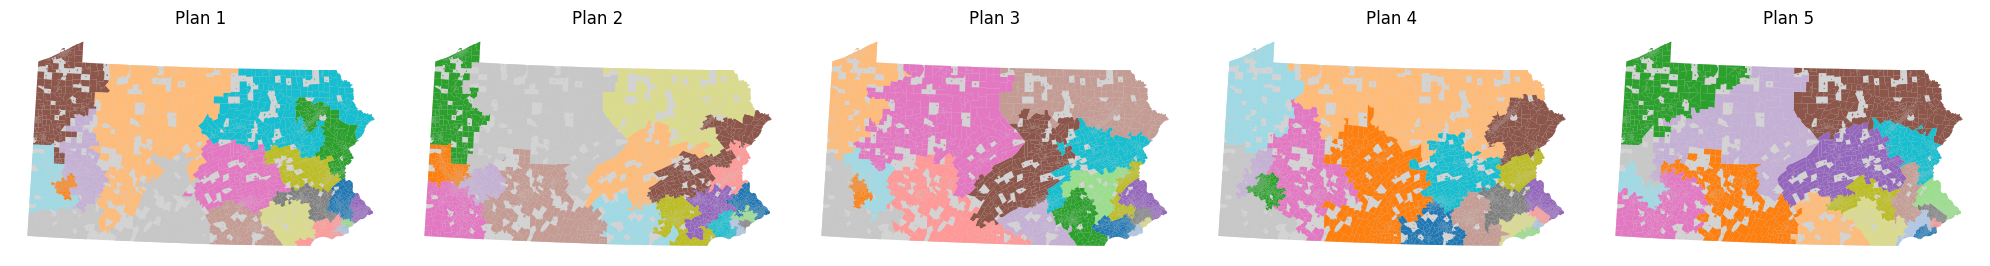

In [59]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file("./PA_shape/PA.shp")

# Same matching approach as before
def geoid_to_key(geoid):
    state = geoid[:2]
    county = geoid[2:5]
    vtd = geoid[5:].lstrip('0') or '0'
    return (state, county, vtd)

id_to_geoid = {node: data["GEOID10"] for node, data in graph.nodes(data=True)}
key_to_geoid = {geoid_to_key(geoid): geoid for geoid in id_to_geoid.values()}

gdf["match_key"] = list(zip(
    gdf["STATEFP10"].astype(str),
    gdf["COUNTYFP10"].astype(str),
    gdf["VTDST10"].astype(str).str.lstrip('0').replace('', '0')
))

gdf["GEOID10_matched"] = gdf["match_key"].map(key_to_geoid)
print(f"Matched: {gdf['GEOID10_matched'].notna().sum()} / {len(gdf)}")

fig, axes = plt.subplots(1, 5, figsize=(20, 8))
axes = axes.flatten()

for i, partition in enumerate(ensemble_list):
    geoid_to_district = {id_to_geoid[node]: district
                         for node, district in partition.assignment.items()}

    gdf["district"] = gdf["GEOID10_matched"].map(geoid_to_district)

    state_outline = gdf.dissolve()
    state_outline.plot(ax=axes[i], color="lightgray", edgecolor="none")

    gdf[gdf["district"].notna()].plot(
        column="district",
        ax=axes[i],
        cmap="tab20",
        legend=False,
        edgecolor="none",
        linewidth=0
    )
    axes[i].set_title(f"Plan {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
for i, partition in enumerate(ensemble_list):
    print(f"Plan {i+1}")
    election_results = partition["PRES12"]
    districts = partition["population"].keys()

    dem_seats = election_results.seats("Dem")
    repub_seats = election_results.seats("Rep")
    print(f"D/R seats: ({dem_seats} / {repub_seats})")


    dem_districts = []
    repub_districts = []
    # iterate through each district
    for district in districts:
        # print(f"District {district}")
        dem = election_results.percents("Dem")[district-1]
        rep = election_results.percents("Rep")[district-1]
        
        if election_results.won("Dem", district):
            dem_districts.append(district)
        else:
            repub_districts.append(district)

        # print(district, dem, rep)
    print(f"Districts Dem Won: {dem_districts}")
    print(f"Districts Repub Won: {repub_districts}")

        

Plan 1
D/R seats: (9 / 9)
Districts Dem Won: [5, 15, 7, 13, 1, 8, 3, 2, 6]
Districts Repub Won: [10, 9, 4, 12, 17, 14, 18, 16, 11]
Plan 2
D/R seats: (8 / 10)
Districts Dem Won: [9, 7, 17, 1, 6, 3, 2, 13]
Districts Repub Won: [5, 14, 10, 4, 16, 18, 12, 11, 8, 15]
Plan 3
D/R seats: (9 / 9)
Districts Dem Won: [11, 3, 6, 15, 1, 13, 8, 2, 16]
Districts Repub Won: [4, 12, 14, 18, 10, 17, 7, 9, 5]
Plan 4
D/R seats: (9 / 9)
Districts Dem Won: [9, 10, 5, 15, 16, 8, 6, 7, 2]
Districts Repub Won: [18, 14, 12, 17, 3, 4, 13, 11, 1]
Plan 5
D/R seats: (8 / 10)
Districts Dem Won: [17, 18, 11, 2, 14, 1, 13, 7]
Districts Repub Won: [5, 9, 3, 12, 8, 10, 4, 15, 16, 6]
